In [1]:
import pandas as pd
from statsmodels.graphics.tukeyplot import results
from unicodedata import category
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

In [2]:
df = pd.read_csv(r'C:\Users\jabes\Desktop\PORTAFOLIO CIENTIFICO DE DATOS\FRAUDE\credit_card_frauds.csv')
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


## Significado de Variables

* Transdatetrans_time = Transaction Date Time
* Merchant = Merchant Name
* Category = Category of Merchant
* amt = Amount of Transaction
* city = City of Credit Card Holder
* State = State of Credit Card Holder
* lat = Latitude Location of Purchase
* Long = Longitude Location of Purchase
* City_pop = Credict Card Holder's City Population
* job = Job od credict card holder
* dob = date of birth of credit card holder
* trans_num = Transaction number
* merch_lat = latitude location of merchant
* merch_long = longitude location of merchant
* is_fraud = cuando la transaccion es fraude es 1 y cuando no es 0

## EDA

In [3]:
print(f'Shape DF: {df.shape}')
print('=*'*30)
print(f'NaN : {df.isna().sum()}')

Shape DF: (339607, 15)
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
NaN : trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

is_fraud
0    99.475276
1     0.524724
Name: proportion, dtype: float64


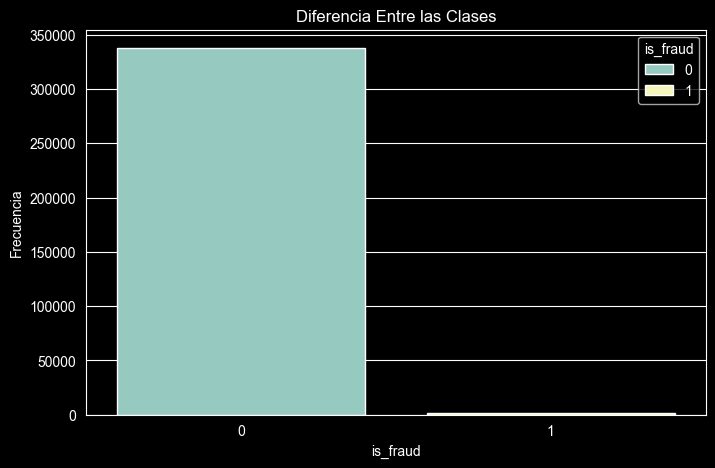

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='is_fraud', hue='is_fraud')
plt.title('Diferencia Entre las Clases')
plt.xlabel('is_fraud')
plt.ylabel('Frecuencia')
print(df['is_fraud'].value_counts(normalize=True)*100)
plt.show()

* Se observa un desbalance notable en la variable is Fraud, indicando que las transacciones buenas son mayores que las malas.

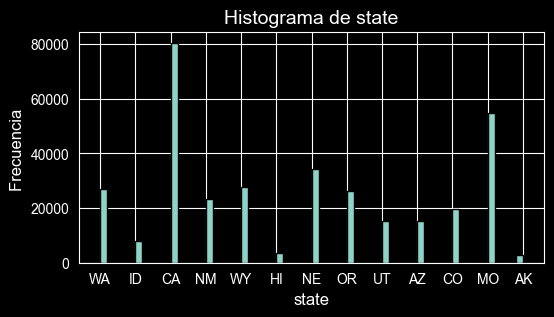

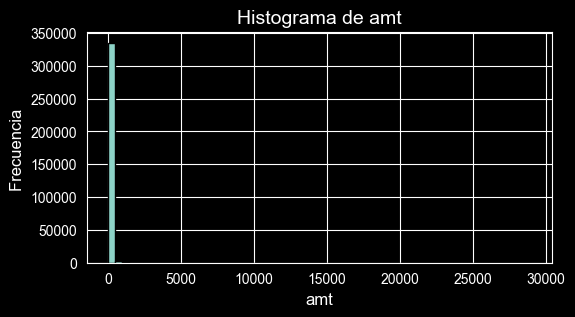

In [6]:
columns=df[['state','amt']]
for col in columns:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=60, edgecolor='black')
    plt.title(f"Histograma de {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frecuencia ", fontsize=12)
    plt.show()

In [7]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


* al no existir variables descriptivas de manera abundante el describe no tiene ningun sentido a no ser que solo se mida la variable is_fraud, la cual muestra un desbalance fuerte entre las clases.

## Feature Engeniering

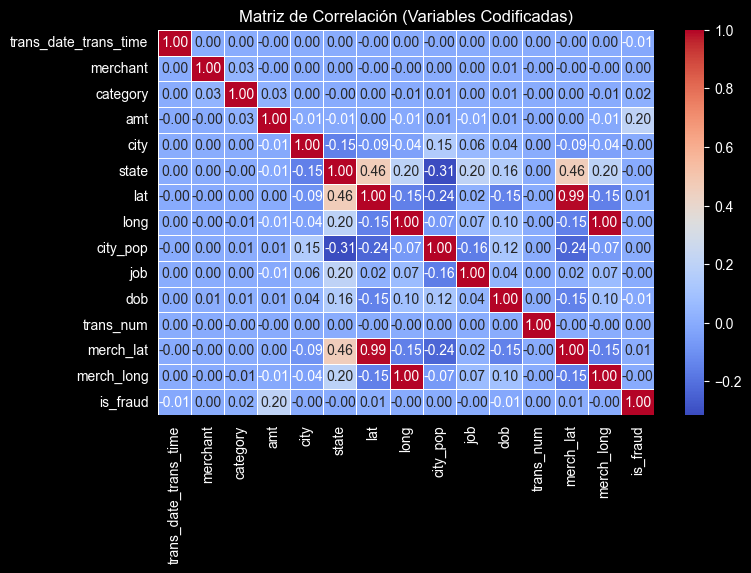

In [8]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()
if 'trans_date' in df_corr.columns:
    df_corr['trans_date'] = pd.to_datetime(df_corr['trans_date']).apply(lambda x: x.toordinal())
if 'trans_time' in df_corr.columns:
    df_corr['trans_time'] = df_corr['trans_time'].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)
# ENCODING
le = LabelEncoder()
columnas_texto = df_corr.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# MATRIZ DE CORRELACION
corr_matrix = df_corr.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5)
plt.title('Matriz de Correlación (Variables Codificadas)')
plt.show()

In [9]:
#Transforme la variable dob a la edad real de cada ciudadano
df['dob'] = pd.to_datetime(df['dob'])
hoy = date.today()
df['edad'] = df['dob'].apply(
    lambda x: hoy.year - x.year - ((hoy.month, hoy.day) < (x.month, x.day)))
columna_a_mover = df.pop('edad')
df.insert(12, 'edad', columna_a_mover)

# SEPARANDO TRANSDATE DE TRANS TIME
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_time'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
columna_a_mover = df.pop('trans_time')
df.insert(1, 'trans_time', columna_a_mover)

# SEPARANDO EL DATE
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_date'] = df['trans_date_trans_time'].dt.date
columna_a_mover = df.pop('trans_date')
df.insert(0, 'trans_date', columna_a_mover)

# Creando Nueva variable distance_km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [10]:
df.drop(columns=['trans_date_trans_time','lat','merch_long','merch_lat','trans_num','merchant','dob'], inplace=True)

In [11]:
df.head()

,trans_date,trans_time,category,amt,city,state,long,city_pop,job,edad,is_fraud,distance_km
0,2019-01-01,0,grocery_pos,107.23,Orient,WA,-118.2105,149,Special educational needs teacher,47,0,30.212176
1,2019-01-01,0,entertainment,220.11,Malad City,ID,-112.2620,4154,Nature conservation officer,64,0,108.206083
2,2019-01-01,0,grocery_pos,96.29,Grenada,CA,-122.5258,589,Systems analyst,80,0,25.059079
3,2019-01-01,0,shopping_pos,7.77,High Rolls Mountain Park,NM,-105.8189,899,Naval architect,58,0,66.021685
4,2019-01-01,0,misc_pos,6.85,Freedom,WY,-111.0292,471,"Education officer, museum",58,0,88.830984


* La variable **is_fraud** presenta una correlación leve con **amt**, lo que sugiere que ciertos montos se desvían del comportamiento transaccional habitual de los clientes. Por otro lado, la relación observada entre **dob y trans_time** se identifica como una correlación efimera; aunque podría especularse una relación con fechas de cumpleaños, al tratarse del registro de nacimiento y no de la fecha del evento, carece de utilidad predictiva y será descartada.

* Se observa una fuerte dependencia entre **job y state**, lo que refleja la concentración geográfica de ciertas profesiones. En consecuencia, las señales principales para la segmentación del modelo serán **amt, edad, state y job**.

* Se creo una nueva Variable **distance_km**, esta ayudara a calcular la distancia en KM de la direccion del ciudadano vs la direccion de donde se ejecuto la transaccion.

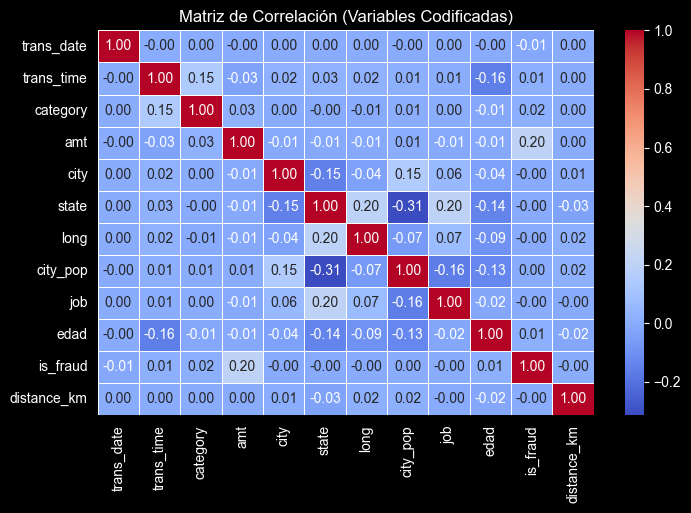

In [12]:
df_corr_t = df.copy()
columnas_texto = df_corr_t.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df_corr_t[col] = le.fit_transform(df_corr_t[col].astype(str))

# MATRIZ DE CORRELACION
corr_matrix = df_corr_t.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5)
plt.title('Matriz de Correlación (Variables Codificadas)')
plt.show()

* Tras la eliminación de variables redundantes que generaban ruido estadístico, se ha logrado una visualización mucho más nítida de los factores que realmente aportan valor al modelo predictivo. Entre los hallazgos más relevantes, destaca la correlación entre category y trans_time. Esta relación sugiere que los usuarios mantienen patrones horarios consistentes según el tipo de artículo o servicio que adquieren, lo cual es vital para que el modelo identifique anomalías de comportamiento.

* Por otro lado, se confirma la estabilidad en la relación entre is_fraud y amt, ratificando al monto transaccional como uno de los indicadores de riesgo más potentes. Finalmente, la variable edad presenta una correlación inversa con otros factores del dataset; este comportamiento es un indicador positivo de que la ingeniería de atributos (feature engineering) fue acertada, proporcionando una señal diferenciadora y robusta para la segmentación de perfiles en el modelo

## Analisis Bivariado de Variables con Mejor Correlacion.

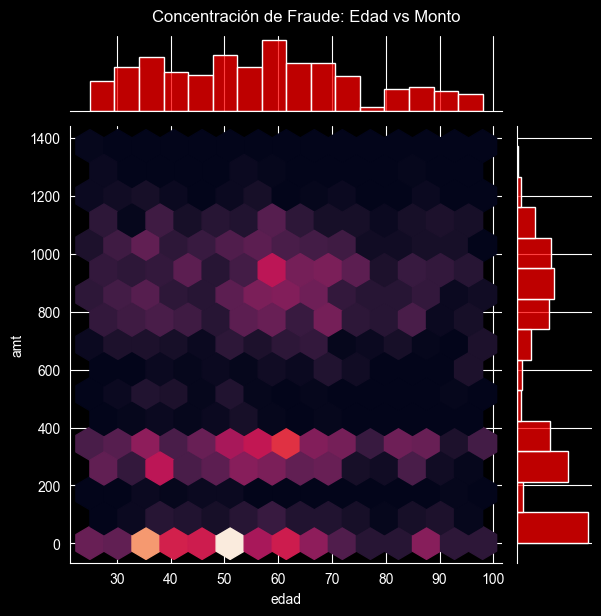

In [13]:
# Solo los casos de fraude
fraude_df = df[df['is_fraud'] == 1]
sns.jointplot(data=fraude_df, x='edad', y='amt', kind='hex', joint_kws=dict(cmap='rocket'),color="red")
plt.suptitle('Concentración de Fraude: Edad vs Monto', y=1.02)
plt.show()

* Se observa que, conforme aumenta la edad del titular, existe una tendencia hacia la realización de gastos de mayor cuantía, osea una mejor capacidad transaccional. tambien este es un indicador de riezgo porque los ciberdelincuentes podrian estar aprovechando esto para realizar el fraude.

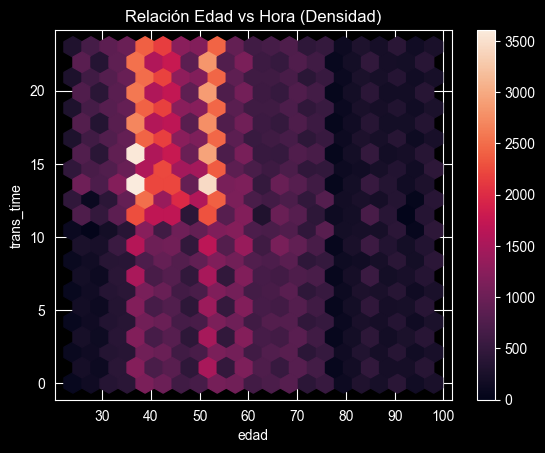

In [14]:
df.plot.hexbin(y='trans_time',x='edad', gridsize=20, cmap='rocket', sharex=False)
plt.title('Relación Edad vs Hora (Densidad)')
plt.show()

* El grafico revela una concentración de actividad en los extremos de la jornada (madrugada y noche cerrada). Este patrón es particularmente relevante para la segmentación de fraude: mientras que en usuarios jóvenes podría reflejar hábitos de consumo nocturno, en segmentos de mayor edad estas transacciones en horas de "baja vigilancia" actúan como un fuerte indicador de anomalía.

* este hallazgo me lleva a crear otra variable llamada hora_extrema, que clasificara las transacciones realizadas de las 22:00 a las 4:00 Horas como transacciones fuera de horario y les dara un flag.

In [15]:
df['hora_extrema'] = df['trans_time'].apply(lambda x: 1 if x >= 22 or x <= 4 else 0)
df.drop(columns=['trans_date'], inplace=True)

In [16]:
df.head(2)

,trans_time,category,amt,city,state,long,city_pop,job,edad,is_fraud,distance_km,hora_extrema
0,0,grocery_pos,107.23,Orient,WA,-118.2105,149,Special educational needs teacher,47,0,30.212176,1
1,0,entertainment,220.11,Malad City,ID,-112.2620,4154,Nature conservation officer,64,0,108.206083,1


## Iniciando Preparacion para Modelo Predictivo.

# Train/test

In [17]:
from sklearn.model_selection import train_test_split

x = df.drop('is_fraud', axis=1)
y= df['is_fraud']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42, shuffle=True, stratify=y)

* separe el conjunto de datos 70/30 para mantener un balance diferente en esta ocacion, utilizare el parametro stratify porque el DataSet es desbalanceado con la variable objetivo, esto me permitira ser mas justo a la hora de la separacion de los conjuntos de entrenamiento y prueba.

# Target Encodign.

In [18]:
df.columns

Index(['trans_time', 'category', 'amt', 'city', 'state', 'long', 'city_pop',
       'job', 'edad', 'is_fraud', 'distance_km', 'hora_extrema'],
      dtype='object')

In [19]:
from category_encoders import TargetEncoder

var = ['city', 'state', 'category', 'job']
en_c = TargetEncoder(cols=var)

# Entrenamiento
x_train_en = en_c.fit_transform(x_train, y_train)

# Prueba (Cambiamos el nombre de y_test_en a x_test_en)
x_test_en = en_c.transform(x_test)

# Limpieza final (Para evitar el error de 'object' que vimos antes)
x_test_en = x_test_en.select_dtypes(exclude=['object'])
x_train_en = x_train_en.select_dtypes(exclude=['object'])

## GridSearch

In [20]:
print(x_train_en.dtypes)

trans_time        int32
category        float64
amt             float64
city            float64
state           float64
long            float64
city_pop          int64
job             float64
edad              int64
distance_km     float64
hora_extrema      int64
dtype: object


In [21]:
from sklearn.model_selection import GridSearchCV
#from sklearn.metrics import f1_Score as f1
import xgboost as xgb

ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

param_grid = [{
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 200,300],
    'scale_pos_weight': [ratio],
    "random_state":[42],
    "subsample": [0.4, 0.9],
    "colsample_bytree": [0.4, 0.9],
    "min_child_weight": [1, 30],


}]

grid_search = GridSearchCV(xgb.XGBClassifier(), param_grid, cv=5, scoring='roc_auc', return_train_score=True)
grid_search.fit(x_train_en, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"[{'colsample_bytree': [0.4, 0.9], 'learning_rate': [0.01, 0.05], 'max_depth': [3, 6, ...], 'min_child_weight': [1, 30], ...}]"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'binary:logistic'


In [22]:
print('Mejores Hiperparametros:', grid_search.best_params_)

Mejores Hiperparametros: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 30, 'n_estimators': 300, 'random_state': 42, 'scale_pos_weight': np.float64(189.63672814755412), 'subsample': 0.9}


* HIPERPARAMETROS GRIDSEARCH
* {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 9, 'min_child_weight': 30, 'n_estimators': 200, 'random_state': 42, 'scale_pos_weight': np.float64(189.63672814755412), 'subsample': 0.9}

## Primera Aproximacion.

In [23]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb

# 1. Instancias el modelo (El ratio debe estar definido previamente)
modelo_base = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=200,
    scale_pos_weight=ratio,
    random_state=42
)

# 2. Entrenas con X codificada y la Y original
modelo_base.fit(x_train_en, y_train)

# Metricas
y_pred = modelo_base.predict(x_test_en)
y_pred_proba = modelo_base.predict_proba(x_test_en)[:, 1]
auc_train = roc_auc_score(y_train, modelo_base.predict_proba(x_train_en)[:, 1])
auc_test = roc_auc_score(y_test, y_pred_proba)

# 4. Métricas
print("ROC-AUC Base:", roc_auc_score(y_test, y_pred_proba))
print( classification_report(y_test, y_pred))
print(f"Diff:      {auc_train - auc_test:.4f}")

ROC-AUC Base: 0.9937990560146422
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    101348
           1       0.28      0.91      0.43       535

    accuracy                           0.99    101883
   macro avg       0.64      0.95      0.71    101883
weighted avg       1.00      0.99      0.99    101883

Diff:      0.0058


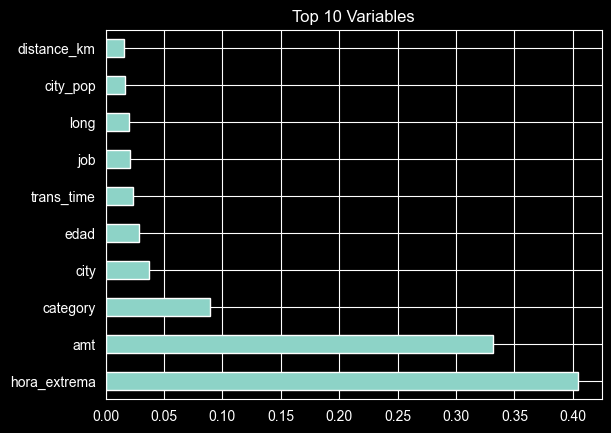

In [24]:
importances = pd.Series(modelo_base.feature_importances_, index=x_train_en.columns)
importances.nlargest(10).plot(kind='barh', title='Top 10 Variables')
plt.show()

In [30]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from scipy.stats import ks_2samp
from optuna.samplers import TPESampler
import optuna, warnings, numpy as np
optuna.logging.set_verbosity(optuna.logging.ERROR)
warnings.filterwarnings("ignore")

device = "cuda" if __import__('subprocess').getoutput("nvidia-smi") != "" else "cpu"

def objective(trial):
    max_d = trial.suggest_int("max_depth", 2, 8)

    params = {
        'colsample_bytree': trial.suggest_float("colsample_bytree", 0.5, 0.9),
        'learning_rate':    trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        'max_depth':        max_d,
        'min_child_weight': trial.suggest_float("min_child_weight", 2, 30, log=True),
        'n_estimators':     trial.suggest_int("n_estimators", 200, 400),
        'random_state':     42,
        'scale_pos_weight': ratio,
        'device':           device,
        'tree_method':      "hist",
        'reg_alpha':        trial.suggest_float("reg_alpha", 1e-3, 6, log=True),
        'reg_lambda':       trial.suggest_float("reg_lambda", 1e-3, 6, log=True),
        'gamma':            trial.suggest_float("gamma", 1e-3, 5, log=True),
        'subsample':        trial.suggest_float("subsample", 0.7, 0.9),
        'eval_metric':      "auc",
        'verbosity':        0
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=555)
    pr_auc_list = []

    for train_idx, val_idx in skf.split(x_train_en, y_train):
        X_tr,  X_val = x_train_en.iloc[train_idx], x_train_en.iloc[val_idx]
        y_tr,  y_val = y_train.iloc[train_idx],    y_train.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        pr_auc_list.append(average_precision_score(y_val, preds))  # ← cambio clave

    return np.mean(pr_auc_list)

In [31]:
results = []

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='fraude_xgb_pr_auc'   # ← nombre actualizado
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMejor PR-AUC CV: {study.best_value:.4f}")   # ← antes decía KS
print(f"Mejores params:  {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Mejor PR-AUC CV: 0.8871
Mejores params:  {'max_depth': 8, 'colsample_bytree': 0.7412754095636725, 'learning_rate': 0.0419707663238856, 'min_child_weight': 2.6935220675532756, 'n_estimators': 391, 'reg_alpha': 0.0586010292265217, 'reg_lambda': 0.007562822127731037, 'gamma': 0.09191408142664403, 'subsample': 0.888349210913288}


In [32]:
# ── Optuna study ──────────────────────────────────────────────
results = []

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='fraude_xgb_pr_auc'
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMejor PR-AUC CV: {study.best_value:.4f}")
print(f"Mejores params:  {study.best_params}")

# ── Función KS ────────────────────────────────────────────────
def calculate_ks(y_true, y_probs):
    df_ks = pd.DataFrame({'target': y_true, 'prob': y_probs})
    buenos = df_ks[df_ks['target'] == 0]['prob']
    malos  = df_ks[df_ks['target'] == 1]['prob']
    ks_stat, _ = ks_2samp(buenos, malos)
    return ks_stat

# ── Modelo final con mejores hiperparámetros ──────────────────
best_params = study.best_params.copy()
best_params['scale_pos_weight'] = ratio
best_params['device']           = device
best_params['tree_method']      = "hist"
best_params['random_state']     = 555
best_params['eval_metric']      = "auc"
best_params['verbosity']        = 0

final_model_xgb = XGBClassifier(**best_params)
final_model_xgb.fit(x_train_en, y_train)

# ── Probabilidades ────────────────────────────────────────────
y_train_probs = final_model_xgb.predict_proba(x_train_en)[:, 1]
y_test_probs  = final_model_xgb.predict_proba(x_test_en)[:, 1]

# ── Métricas ──────────────────────────────────────────────────
from sklearn.metrics import average_precision_score, precision_recall_curve

auc_train  = roc_auc_score(y_train, y_train_probs)
auc_test   = roc_auc_score(y_test,  y_test_probs)
ks_train   = calculate_ks(y_train, y_train_probs)
ks_test    = calculate_ks(y_test,  y_test_probs)
pr_auc_train = average_precision_score(y_train, y_train_probs)
pr_auc_test  = average_precision_score(y_test,  y_test_probs)
diff       = auc_train - auc_test

# Threshold óptimo por F1
prec, rec, thresholds = precision_recall_curve(y_test, y_test_probs)
f1_scores  = 2 * prec * rec / (prec + rec + 1e-9)
best_thresh = thresholds[f1_scores.argmax()]
y_pred_opt  = (y_test_probs >= best_thresh).astype(int)

print(f"\nAUC Train:        {auc_train:.4f}")
print(f"AUC Test:         {auc_test:.4f}")
print(f"Diff (Overfit):   {diff:.4f} ({(diff/auc_test)*100:.2f}%)")
print(f"KS Test:          {ks_test:.2%}")
print(f"PR-AUC Train:     {pr_auc_train:.4f}")
print(f"PR-AUC Test:      {pr_auc_test:.4f}")
print(f"Threshold óptimo: {best_thresh:.4f}")
print(f"\n{classification_report(y_test, y_pred_opt)}")

# ── Results table ─────────────────────────────────────────────
results.append({
    "Model":        "XGBoost + Optuna (PR-AUC)",
    "AUC Train":    round(auc_train,     4),
    "AUC Test":     round(auc_test,      4),
    "KS Train":     round(ks_train,      4),
    "KS Test":      round(ks_test,       4),
    "PR-AUC Train": round(pr_auc_train,  4),
    "PR-AUC Test":  round(pr_auc_test,   4),
    "Diff":         round(diff,          4)
})

results_df = pd.DataFrame(results)
results_df

  0%|          | 0/50 [00:00<?, ?it/s]


Mejor PR-AUC CV: 0.8871
Mejores params:  {'max_depth': 8, 'colsample_bytree': 0.7412754095636725, 'learning_rate': 0.0419707663238856, 'min_child_weight': 2.6935220675532756, 'n_estimators': 391, 'reg_alpha': 0.0586010292265217, 'reg_lambda': 0.007562822127731037, 'gamma': 0.09191408142664403, 'subsample': 0.888349210913288}

AUC Train:        1.0000
AUC Test:         0.9942
Diff (Overfit):   0.0058 (0.58%)
KS Test:          93.42%
PR-AUC Train:     0.9989
PR-AUC Test:      0.8674
Threshold óptimo: 0.9542

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101348
           1       0.91      0.75      0.82       535

    accuracy                           1.00    101883
   macro avg       0.95      0.87      0.91    101883
weighted avg       1.00      1.00      1.00    101883



,Model,AUC Train,AUC Test,KS Train,KS Test,PR-AUC Train,PR-AUC Test,Diff
0,XGBoost + Optuna (PR-AUC),1.0,0.9942,0.9998,0.9342,0.9989,0.8674,0.0058


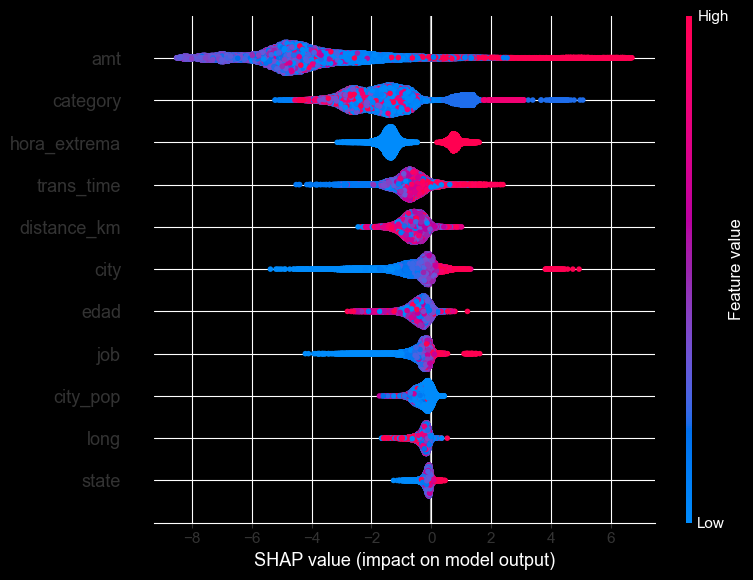

In [33]:
import shap
import matplotlib.pyplot as plt

# 1. Crear el explicador SHAP optimizado para modelos de árboles (TreeExplainer)
explainer = shap.TreeExplainer(final_model_xgb)

# 2. Calcular los valores SHAP para el set de prueba (puedes usar una muestra si es muy grande)
# Usamos x_test_en que es la data ya procesada y codificada
shap_values = explainer.shap_values(x_test_en)

# 3. Gráfico de resumen (Summary Plot)
# Este gráfico muestra la distribución del impacto de cada variable
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test_en, plot_type="dot")